# **Pandemic Z: Optimizing Group Size for Survival in a Resource-Limited Zombie Outbreak**

## Import Library and Data

In [ ]:
# Import librares
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
sns.set_style("darkgrid")

In [ ]:
# Import dataset
low2 = pd.read_csv('low2.csv')
low3 = pd.read_csv('low3.csv')
low4 = pd.read_csv('low4.csv')
mid = pd.read_csv('mid.csv')
high = pd.read_csv('high.csv')

In [ ]:
df = pd.concat([low2, low3, low4, mid, high], ignore_index=True)

## Data Summary

In [ ]:
df.head()

,[run number],initial-zombie-population,initial-human-population,[step],survival-rate,resource-efficiency,conflict
0,3,8,2,0,100.0,930.49500,0
1,2,8,2,0,100.0,603.43750,0
2,1,8,2,0,100.0,669.60000,0
3,3,8,2,1,100.0,940.81325,0
4,3,8,2,2,100.0,966.73500,0


In [ ]:
df.tail()

,[run number],initial-zombie-population,initial-human-population,[step],survival-rate,resource-efficiency,conflict
1784379,150,8,10,4996,30.0,1141.333333,0
1784380,150,8,10,4997,30.0,1141.333333,0
1784381,150,8,10,4998,30.0,1141.333333,0
1784382,150,8,10,4999,30.0,1141.333333,0
1784383,150,8,10,5000,30.0,1141.333333,0


In [ ]:
df.columns

Index(['[run number]', 'initial-zombie-population', 'initial-human-population',
       '[step]', 'survival-rate', 'resource-efficiency', 'conflict'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1784384 entries, 0 to 1784383
Data columns (total 7 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   [run number]               int64  
 1   initial-zombie-population  int64  
 2   initial-human-population   int64  
 3   [step]                     int64  
 4   survival-rate              float64
 5   resource-efficiency        float64
 6   conflict                   int64  
dtypes: float64(2), int64(5)
memory usage: 95.3 MB


In [ ]:
df.describe()

,[run number],initial-zombie-population,initial-human-population,[step],survival-rate,resource-efficiency,conflict
count,1.784384e+06,1784384.0,1.784384e+06,1.784384e+06,1.784384e+06,1.784384e+06,1.784384e+06
mean,6.345709e+01,8.0,6.522585e+00,2.343819e+03,4.749899e+01,1.483790e+03,1.126596e+00
std,4.403720e+01,0.0,2.451884e+00,1.472808e+03,2.805813e+01,1.004660e+03,3.416404e+00
min,1.000000e+00,8.0,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.500000e+01,8.0,5.000000e+00,1.022000e+03,2.500000e+01,6.401966e+02,0.000000e+00
50%,5.200000e+01,8.0,7.000000e+00,2.260000e+03,4.000000e+01,1.225255e+03,0.000000e+00
75%,1.010000e+02,8.0,9.000000e+00,3.626000e+03,6.666667e+01,2.686000e+03,1.000000e+00
max,1.500000e+02,8.0,1.000000e+01,5.000000e+03,1.000000e+02,3.597000e+03,4.000000e+01


## Data Preparation

In [ ]:
# Rename columns for convenience (optional)
df.rename(columns={
    '[run number]': 'run_number',
    'initial-human-population': 'group_size',
    '[step]': 'step',
    'survival-rate': 'survival_rate',
    'resource-efficiency': 'resource_efficiency',
    'conflict': 'conflict'
}, inplace=True)

In [ ]:
# Make sure group_size is numeric
df['group_size'] = df['group_size'].astype(int)

## Data Visualization

In [ ]:
run_sum = df.groupby(['run_number', 'group_size']).agg(
    survival_rate=('survival_rate', 'mean'),
    resource_efficiency=('resource_efficiency', 'mean'),
    conflict=('conflict', 'mean')
).reset_index()
run_sum.tail(10)

,run_number,group_size,survival_rate,resource_efficiency,conflict
440,146,7,68.162119,832.164170,3.989888
441,146,10,41.581684,700.689820,0.000000
442,147,7,72.494073,604.905635,0.000000
443,147,10,49.636073,629.756339,0.000000
444,148,7,44.145457,1175.511789,3.921216
445,148,10,23.657269,2006.379378,0.000000
446,149,7,83.740395,481.976292,0.000000
447,149,10,40.439912,847.364381,0.000000
448,150,7,26.189048,2129.146792,0.000000
449,150,10,37.524495,945.836095,0.000000


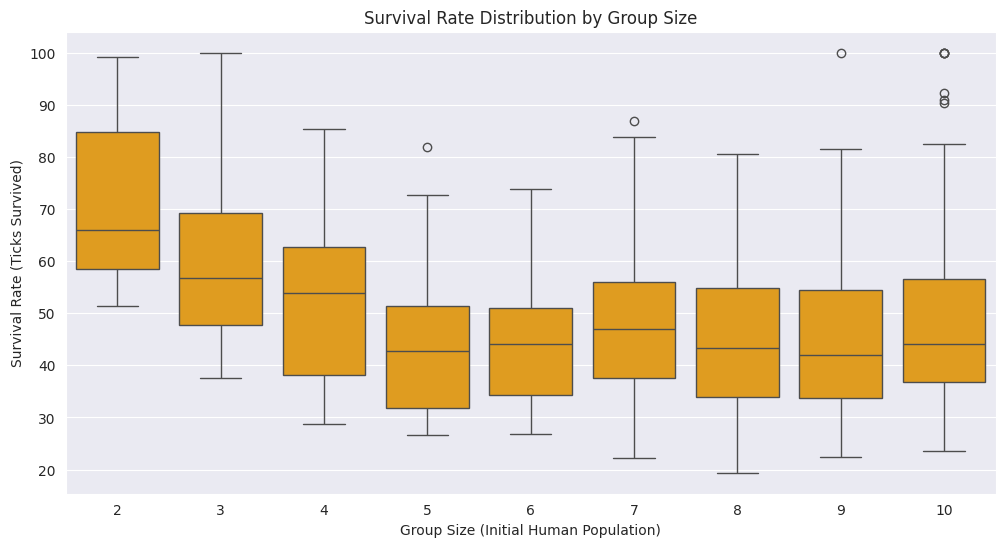

In [ ]:
# Visualize survival rate by group size
plt.figure(figsize=(12, 6))
sns.boxplot(x='group_size', y='survival_rate', data=run_sum, color="orange")
plt.title('Survival Rate Distribution by Group Size')
plt.xlabel('Group Size (Initial Human Population)')
plt.ylabel('Survival Rate (Ticks Survived)')
plt.show()

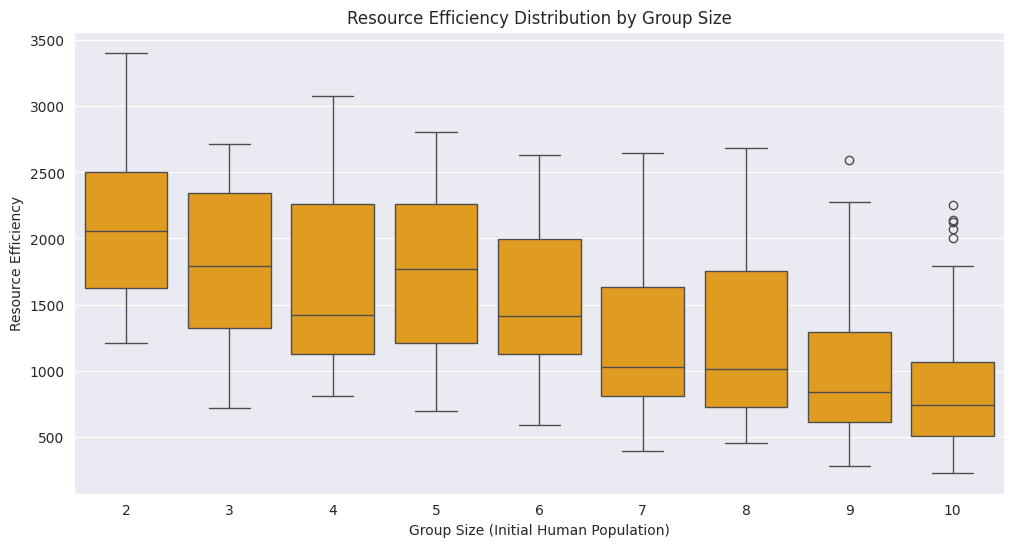

In [ ]:
# Visualize resource efficiency by group size
plt.figure(figsize=(12, 6))
sns.boxplot(x='group_size', y='resource_efficiency', data=run_sum, color="orange")
plt.title('Resource Efficiency Distribution by Group Size')
plt.xlabel('Group Size (Initial Human Population)')
plt.ylabel('Resource Efficiency')
plt.show()

In [ ]:
# Aggregate average conflict by step and group size
conflict_over_time = df.groupby(['step', 'group_size']).agg(
    avg_conflict=('conflict', 'mean')
).reset_index()

<ipython-input-187-7de313bf457e>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=conflict_over_time, x='step', y='avg_conflict', hue='group_size', ci='sd', palette="YlOrRd")


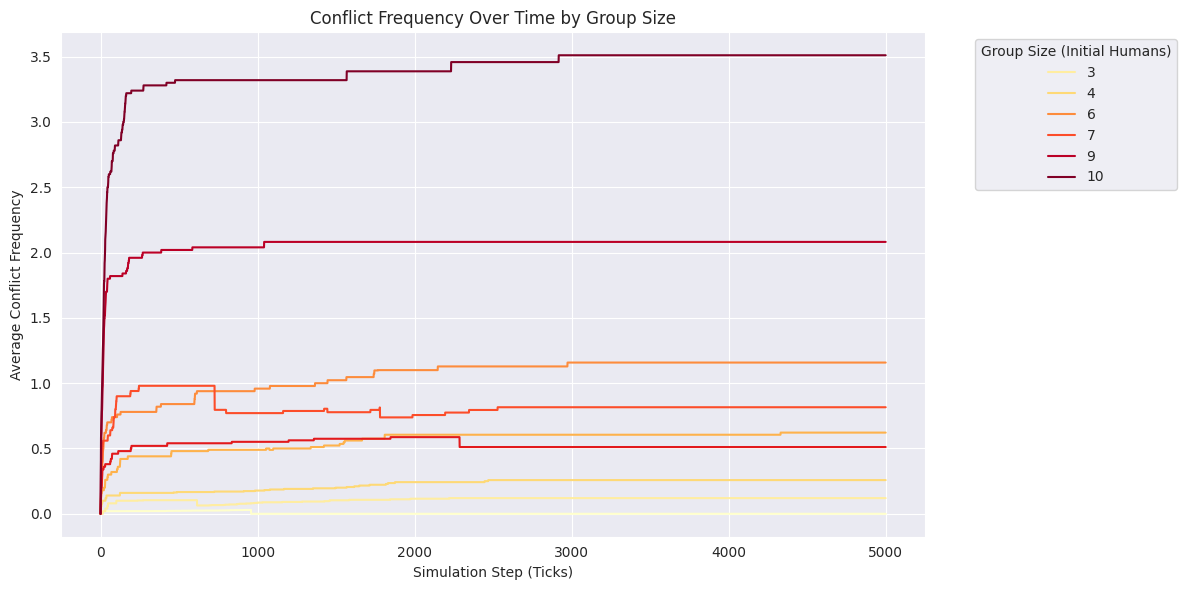

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=conflict_over_time, x='step', y='avg_conflict', hue='group_size', ci='sd', palette="YlOrRd")

plt.title('Conflict Frequency Over Time by Group Size')
plt.xlabel('Simulation Step (Ticks)')
plt.ylabel('Average Conflict Frequency')

plt.legend(title='Group Size (Initial Humans)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()  # adjust layout to fit legend

plt.show()

In [ ]:
 # Prepare data for ANOVA tests
survival_groups = [group['survival_rate'].values for _, group in run_sum.groupby('group_size')]
resource_groups = [group['resource_efficiency'].values for _, group in run_sum.groupby('group_size')]
conflict_groups = [group['conflict'].values for _, group in run_sum.groupby('group_size')]

In [ ]:
# One-way ANOVA: Survival Rate
f_surv, p_surv = stats.f_oneway(*survival_groups)
print(f"ANOVA Survival Rate: F = {f_surv:.4f}, p = {p_surv:.4e}")

# One-way ANOVA: Resource Efficiency
f_res, p_res = stats.f_oneway(*resource_groups)
print(f"ANOVA Resource Efficiency: F = {f_res:.4f}, p = {p_res:.4e}")

# One-way ANOVA: Conflict
f_conf, p_conf = stats.f_oneway(*conflict_groups)
print(f"ANOVA Conflict: F = {f_conf:.4f}, p = {p_conf:.4e}")

ANOVA Survival Rate: F = 16.1324, p = 5.8483e-21
ANOVA Resource Efficiency: F = 22.4429, p = 9.0165e-29
ANOVA Conflict: F = 6.6371, p = 3.3143e-08


In [ ]:
alpha = 0.01
if p_surv < alpha:
    print(f"Survival rate differs significantly across group sizes (p < {alpha})")
else:
    print(f"No significant difference in survival rate across group sizes (p ≥ {alpha})")

if p_res < alpha:
    print(f"Resource efficiency differs significantly across group sizes (p < {alpha})")
else:
    print(f"No significant difference in resource efficiency across group sizes (p ≥ {alpha})")

if p_conf < alpha:
    print(f"Conflict frequency differs significantly across group sizes (p < {alpha})")
else:
    print(f"No significant difference in conflict frequency across group sizes (p ≥ {alpha})")

Survival rate differs significantly across group sizes (p < 0.01)
Resource efficiency differs significantly across group sizes (p < 0.01)
Conflict frequency differs significantly across group sizes (p < 0.01)


In [ ]:

# Post-hoc pairwise test if ANOVA is significant
if p_surv < alpha:
    tukey_surv = pairwise_tukeyhsd(endog=run_sum['survival_rate'],
                                   groups=run_sum['group_size'],
                                   alpha=alpha)
    print(tukey_surv)

if p_res < alpha:
    tukey_res = pairwise_tukeyhsd(endog=run_sum['resource_efficiency'],
                                  groups=run_sum['group_size'],
                                  alpha=alpha)
    print(tukey_res)

if p_conf < alpha:
    tukey_conf = pairwise_tukeyhsd(endog=run_sum['conflict'],
                                   groups=run_sum['group_size'],
                                   alpha=alpha)
    print(tukey_conf)

 Multiple Comparison of Means - Tukey HSD, FWER=0.01  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     2      3 -11.6357 0.0055 -22.7612  -0.5101   True
     2      4 -18.5447    0.0 -29.6702  -7.4192   True
     2      5 -26.1449    0.0 -37.2704 -15.0194   True
     2      6 -26.2383    0.0 -37.3639 -15.1128   True
     2      7 -22.7186    0.0 -33.8442 -11.5931   True
     2      8 -26.0091    0.0 -37.1347 -14.8836   True
     2      9   -24.53    0.0 -35.6555 -13.4044   True
     2     10 -19.8917    0.0 -31.0172  -8.7662   True
     3      4   -6.909  0.378 -18.0346   4.2165  False
     3      5 -14.5092 0.0001 -25.6348  -3.3837   True
     3      6 -14.6027 0.0001 -25.7282  -3.4772   True
     3      7  -11.083 0.0105 -22.2085   0.0425  False
     3      8 -14.3735 0.0001  -25.499  -3.2479   True
     3      9 -12.8943 0.0011 -24.0198  -1.7688   True
     3     10  -8.2561 0.1567 -19.3816   2.8695  False
     4    

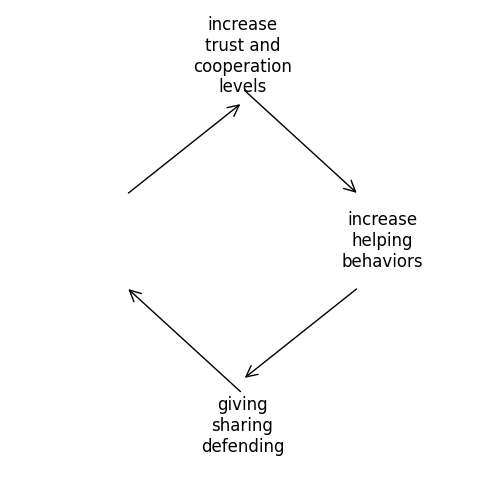

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Texts
ax.text(5, 9, "increase\ntrust and\ncooperation\nlevels", ha='center', va='center', fontsize=12)
ax.text(8, 5, "increase\nhelping\nbehaviors", ha='center', va='center', fontsize=12)
ax.text(5, 1, "giving\nsharing\ndefending", ha='center', va='center', fontsize=12)

# Arrows (circular style)
arrow1 = FancyArrowPatch((5, 8.3), (7.5, 6), arrowstyle='->', mutation_scale=20)
arrow2 = FancyArrowPatch((7.5, 4), (5, 2), arrowstyle='->', mutation_scale=20)
arrow3 = FancyArrowPatch((5, 1.7), (2.5, 4), arrowstyle='->', mutation_scale=20)
arrow4 = FancyArrowPatch((2.5, 6), (5, 8), arrowstyle='->', mutation_scale=20)

for arrow in [arrow1, arrow2, arrow3, arrow4]:
    ax.add_patch(arrow)

plt.show()
